# Model comparison

In [21]:
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Unset this to run locally
USE_COLAB = True

In [22]:
if USE_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    import os

    # Set this to root directory where data_v2 folder is
    PATH = "/content/drive/MyDrive/enpm703/group_proj/ENPM703-Group4"
    os.chdir(PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data setup

In [23]:
DATA_DIR = Path("data_V2")
TRAIN_SEASONS = ["2020-21", "2021-22", "2022-23", "2023-24"]
VAL_SEASON = "2024-25"
TEST_SEASON = "2025-26"
HORIZONS = [1, 2, 3, 4]

feature_cols_final = [
    "lag1_rel",
    "lag2_rel",
    "lag3_rel",
    "lag4_rel",
    "wow_pct_lag1",
    "wow_pct_lag2",
    "roll4_cv",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "is_onset_zone",
    "is_peak_zone",
    "covid_suppressed",
    "flu_search_index_lag1",
]

model_df_final = pd.read_csv(DATA_DIR / "flu_features.csv", parse_dates=["date"])
combined_df = pd.read_csv(DATA_DIR / "flu_features_combined.csv", parse_dates=["date"])

## Functions

In [24]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # using gpu if available to make things faster
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_split(horizon: int):
    target_col = f"target_rel_h{horizon}"
    admissions_col = f"weekly_admissions_h{horizon}"
    required = feature_cols_final + [target_col]

    train = combined_df[combined_df["season"].isin(TRAIN_SEASONS)].dropna(subset=required).copy()
    val = model_df_final[model_df_final["season"] == VAL_SEASON].dropna(subset=required).copy()
    test = model_df_final[model_df_final["season"] == TEST_SEASON].dropna(subset=required).copy()

    scaler = StandardScaler()
    scaler.fit(train[feature_cols_final])

    return {
        "train": train,
        "val": val,
        "test": test,
        "X_train": scaler.transform(train[feature_cols_final]),
        "X_val": scaler.transform(val[feature_cols_final]),
        "X_test": scaler.transform(test[feature_cols_final]),
        "y_train": train[target_col].values,
        "y_val": val[target_col].values,
        "y_test": test[target_col].values,
        "train_actual": train[admissions_col].values,
        "val_actual": val[admissions_col].values,
        "test_actual": test[admissions_col].values,
    }

def evaluate(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = float(np.mean(np.abs(actual - predicted)))
    rmse = float(np.sqrt(np.mean((actual - predicted) ** 2)))
    mape = float(np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100)
    return {"mae": mae, "rmse": rmse, "mape": mape}

def paired_ttest_summary(left_scores, right_scores):
    left = np.asarray(left_scores, dtype=float)
    right = np.asarray(right_scores, dtype=float)
    diff = left - right
    t_stat, p_value = stats.ttest_rel(left, right)
    return {
        "n": int(len(diff)),
        "mean_left": float(left.mean()),
        "mean_right": float(right.mean()),
        "mean_diff": float(diff.mean()),
        "std_diff": float(diff.std(ddof=1)) if len(diff) > 1 else 0.0,
        "t_stat": float(t_stat),
        "p_value": float(p_value),
    }

## Model setup

### Neural net:

In [25]:
class FluForecastNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.3):
        super().__init__()

        layers = []
        in_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

MLP_GRID = [
    {"hidden_dims": (64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden_dims": (32, 16), "dropout": 0.2, "lr": 5e-4},
]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_mlp(X_train, y_train, X_val, y_val, seed, params, epochs=150, batch_size=16):
    set_seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)

    model = FluForecastNet(
        input_dim=X_train.shape[1],
        hidden_dims=params["hidden_dims"],
        dropout=params["dropout"],
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True,
    )

    best_state = None
    best_val_loss = float("inf")
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        scheduler.step(val_loss)

    model.load_state_dict(best_state)
    return model, best_val_loss


def predict_mlp(model, X, roll4_values):
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        pred_rel = model(X_t).detach().cpu().numpy().ravel()
    return np.expm1(pred_rel + np.log1p(np.asarray(roll4_values, dtype=float)))

### Tree/linear

In [26]:
XGB_PARAMS = {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0}
LGBM_PARAMS = {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0, "min_child_samples": 5, "device_type": "gpu"}
RIDGE_ALPHA = 1000.0

def fit_tree_models(seed, split):
    set_seed(seed)
    xgb = XGBRegressor(random_state=seed, **XGB_PARAMS)
    xgb.fit(split["X_train"], split["y_train"])

    lgbm = LGBMRegressor(random_state=seed, verbose=-1, **LGBM_PARAMS)
    lgbm.fit(split["X_train"], split["y_train"])

    ridge = Ridge(alpha=RIDGE_ALPHA)
    ridge.fit(split["X_train"], split["y_train"])

    return {"xgb": xgb, "lgbm": lgbm, "ridge": ridge}


def predict_tree(model, X, roll4_values):
    return np.expm1(model.predict(X) + np.log1p(np.asarray(roll4_values, dtype=float)))

## Comparison



In [27]:
RANDOM_SEEDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,15] # values don't matter, just need to be different

results = []
for horizon in HORIZONS:
    for seed in RANDOM_SEEDS:
        print(f"Running horizon={horizon}, seed={seed}")

        split = build_split(horizon)
        row_base = {"seed": seed, "horizon": horizon}

        best_mlp = (None, None)
        best_val_loss = float("inf")
        for params in MLP_GRID:
            model, val_loss = train_mlp(split["X_train"], split["y_train"], split["X_val"], split["y_val"], seed, params, batch_size=64)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_mlp = (model, params)
        mlp_model, _ = best_mlp
        mlp_val_pred = predict_mlp(mlp_model, split["X_val"], split["val"]["roll4"].values)
        mlp_test_pred = predict_mlp(mlp_model, split["X_test"], split["test"]["roll4"].values)

        tree_models = fit_tree_models(seed, split)
        xgb_val_pred = predict_tree(tree_models["xgb"], split["X_val"], split["val"]["roll4"].values)
        xgb_test_pred = predict_tree(tree_models["xgb"], split["X_test"], split["test"]["roll4"].values)
        lgbm_val_pred = predict_tree(tree_models["lgbm"], split["X_val"], split["val"]["roll4"].values)
        lgbm_test_pred = predict_tree(tree_models["lgbm"], split["X_test"], split["test"]["roll4"].values)
        ridge_val_pred = predict_tree(tree_models["ridge"], split["X_val"], split["val"]["roll4"].values)
        ridge_test_pred = predict_tree(tree_models["ridge"], split["X_test"], split["test"]["roll4"].values)

        rows = [
            {**row_base, "model": "MLP", "split": "val", "mae": evaluate(split["val_actual"], mlp_val_pred)["mae"], "rmse": evaluate(split["val_actual"], mlp_val_pred)["rmse"]},
            {**row_base, "model": "MLP", "split": "test", "mae": evaluate(split["test_actual"], mlp_test_pred)["mae"], "rmse": evaluate(split["test_actual"], mlp_test_pred)["rmse"]},
            {**row_base, "model": "XGBoost", "split": "val", "mae": evaluate(split["val_actual"], xgb_val_pred)["mae"], "rmse": evaluate(split["val_actual"], xgb_val_pred)["rmse"]},
            {**row_base, "model": "XGBoost", "split": "test", "mae": evaluate(split["test_actual"], xgb_test_pred)["mae"], "rmse": evaluate(split["test_actual"], xgb_test_pred)["rmse"]},
            {**row_base, "model": "LightGBM", "split": "val", "mae": evaluate(split["val_actual"], lgbm_val_pred)["mae"], "rmse": evaluate(split["val_actual"], lgbm_val_pred)["rmse"]},
            {**row_base, "model": "LightGBM", "split": "test", "mae": evaluate(split["test_actual"], lgbm_test_pred)["mae"], "rmse": evaluate(split["test_actual"], lgbm_test_pred)["rmse"]},
            {**row_base, "model": "Ridge", "split": "val", "mae": evaluate(split["val_actual"], ridge_val_pred)["mae"], "rmse": evaluate(split["val_actual"], ridge_val_pred)["rmse"]},
            {**row_base, "model": "Ridge", "split": "test", "mae": evaluate(split["test_actual"], ridge_test_pred)["mae"], "rmse": evaluate(split["test_actual"], ridge_test_pred)["rmse"]},
            {**row_base, "model": "Rolling Mean", "split": "val", "mae": evaluate(split["val_actual"], split["val"]["roll4"].values)["mae"], "rmse": evaluate(split["val_actual"], split["val"]["roll4"].values)["rmse"]},
            {**row_base, "model": "Rolling Mean", "split": "test", "mae": evaluate(split["test_actual"], split["test"]["roll4"].values)["mae"], "rmse": evaluate(split["test_actual"], split["test"]["roll4"].values)["rmse"]},
        ]

        results.extend(rows)

results_df = pd.DataFrame(results)
results_df.to_csv(DATA_DIR / "model_comparison_runs.csv", index=False)
results_df.head()

Running horizon=1, seed=1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Running horizon=1, seed=2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Running horizon=1, seed=3


...

Running horizon=4, seed=14


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Running horizon=4, seed=15


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,seed,horizon,model,split,mae,rmse
0,1,1,MLP,val,2944.394555,4656.822744
1,1,1,MLP,test,2671.976258,4527.745681
2,1,1,XGBoost,val,4186.620687,6438.220246
3,1,1,XGBoost,test,2009.724966,3351.741062
4,1,1,LightGBM,val,4543.363177,7040.375913


## Comparison summary

Shows the average MAE for each horizon and seed and model.

In [28]:
test_df = results_df[results_df["split"] == "test"].copy()
summary_df = (
    test_df.groupby(["horizon", "model"], as_index=False)
    .agg(mean_mae=("mae", "mean"), std_mae=("mae", "std"), mean_rmse=("rmse", "mean"))
    .sort_values(["horizon", "mean_mae"])
)
summary_df

,horizon,model,mean_mae,std_mae,mean_rmse
4,1,XGBoost,1942.113258,79.741736,3353.535161
0,1,LightGBM,2057.923015,60.051121,3602.385461
1,1,MLP,2147.017339,237.727412,3972.387573
2,1,Ridge,2405.289756,0.000000,4740.320111
3,1,Rolling Mean,5363.798387,0.000000,8506.835342
6,2,MLP,3516.201494,260.441734,6836.954792
7,2,Ridge,3939.432055,0.000000,7810.728154
9,2,XGBoost,4570.048569,135.821005,7673.644331
5,2,LightGBM,4801.924479,70.444894,7941.109905
8,2,Rolling Mean,7325.725000,0.000000,10743.304603


## Paired t-tests against Ridge

Compares Ridge to every other model within the same seed. This tells us if the difference in mean error is consistently above or below zero.

In [29]:
comparisons = []
for horizon in HORIZONS:
    horizon_df = test_df[test_df["horizon"] == horizon]
    ridge_scores = horizon_df[horizon_df["model"] == "Ridge"].set_index("seed")["mae"]
    for model_name in ["MLP", "XGBoost", "LightGBM"]:
        model_scores = horizon_df[horizon_df["model"] == model_name].set_index("seed")["mae"]
        aligned = pd.concat([model_scores, ridge_scores], axis=1, join="inner")
        aligned.columns = ["model", "ridge"]
        stats_row = paired_ttest_summary(aligned["model"], aligned["ridge"])
        stats_row.update({"horizon": horizon, "model": model_name, "baseline": "Ridge"})
        comparisons.append(stats_row)

comparison_df = pd.DataFrame(comparisons)
comparison_df

,n,mean_left,mean_right,mean_diff,std_diff,t_stat,p_value,horizon,model,baseline
0,15,2147.017339,2405.289756,-258.272417,237.727412,-4.207696,8.773195e-04,1,MLP,Ridge
1,15,1942.113258,2405.289756,-463.176498,79.741736,-22.496060,2.171464e-12,1,XGBoost,Ridge
2,15,2057.923015,2405.289756,-347.366740,60.051121,-22.403339,2.297356e-12,1,LightGBM,Ridge
3,15,3516.201494,3939.432055,-423.230561,260.441734,-6.293787,1.975840e-05,2,MLP,Ridge
4,15,4570.048569,3939.432055,630.616514,135.821005,17.982250,4.522639e-11,2,XGBoost,Ridge
5,15,4801.924479,3939.432055,862.492425,70.444894,47.418892,7.294802e-17,2,LightGBM,Ridge
6,15,4814.198020,4917.516168,-103.318148,285.748752,-1.400354,1.831787e-01,3,MLP,Ridge
7,15,6728.230803,4917.516168,1810.714635,144.873231,48.406925,5.474454e-17,3,XGBoost,Ridge
8,15,6845.327655,4917.516168,1927.811487,71.355475,104.636424,1.160970e-21,3,LightGBM,Ridge
9,15,5362.329158,5303.434354,58.894804,357.318807,0.638362,5.335423e-01,4,MLP,Ridge


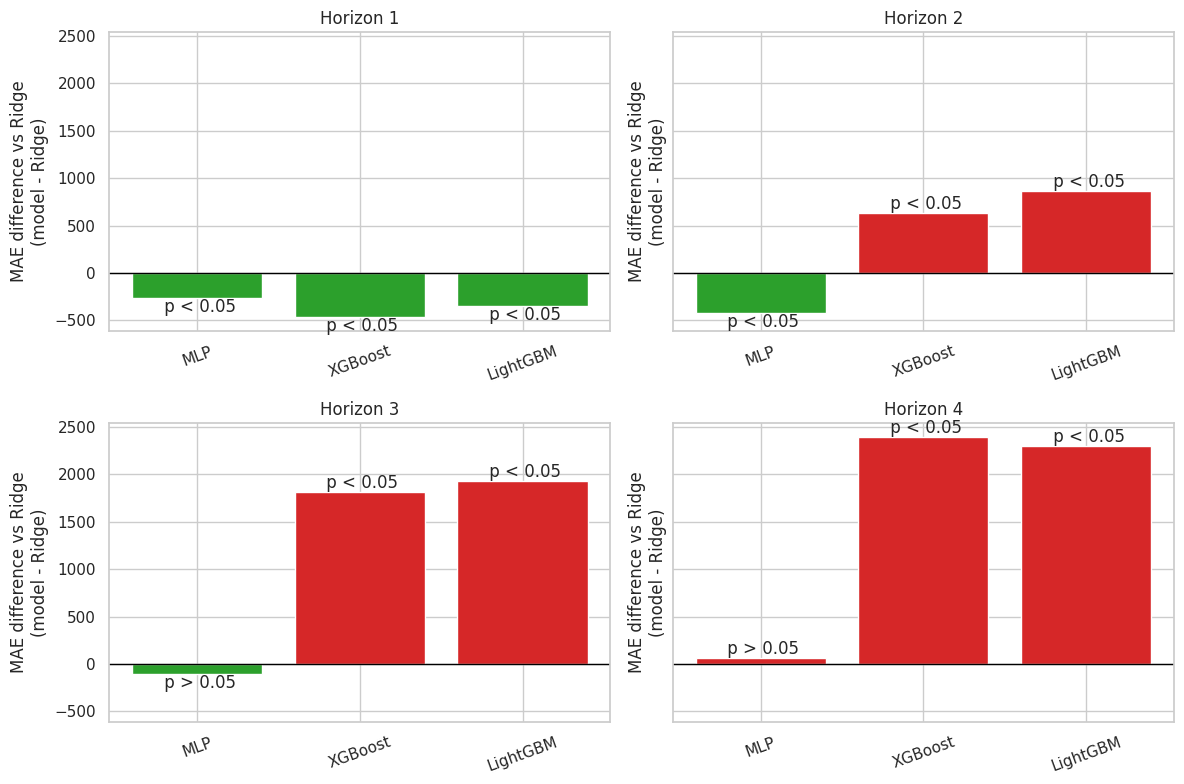

In [30]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = comparison_df.sort_values(["horizon", "model"]).copy()
model_order = ["MLP", "XGBoost", "LightGBM"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, horizon in zip(axes, sorted(plot_df["horizon"].unique())):
    sub = plot_df[plot_df["horizon"] == horizon].set_index("model").reindex(model_order)

    colors = ["tab:green" if v < 0 else "tab:red" for v in sub["mean_diff"]]
    bars = ax.bar(sub.index, sub["mean_diff"], color=colors)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Horizon {horizon}")
    ax.set_ylabel("MAE difference vs Ridge\n(model - Ridge)")
    ax.tick_params(axis="x", rotation=20)

    for bar, p in zip(bars, sub["p_value"]):
        y = bar.get_height()
        label = "p < 0.05" if p < 0.05 else "p > 0.05"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f" {label}",
            ha="center",
            va="bottom" if y >= 0 else "top",
        )

plt.tight_layout()
plt.show()

## Summary

In [31]:
summary_view = summary_df.sort_values(["horizon", "mean_mae"]).reset_index(drop=True)
summary_view

,horizon,model,mean_mae,std_mae,mean_rmse
0,1,XGBoost,1942.113258,79.741736,3353.535161
1,1,LightGBM,2057.923015,60.051121,3602.385461
2,1,MLP,2147.017339,237.727412,3972.387573
3,1,Ridge,2405.289756,0.000000,4740.320111
4,1,Rolling Mean,5363.798387,0.000000,8506.835342
5,2,MLP,3516.201494,260.441734,6836.954792
6,2,Ridge,3939.432055,0.000000,7810.728154
7,2,XGBoost,4570.048569,135.821005,7673.644331
8,2,LightGBM,4801.924479,70.444894,7941.109905
9,2,Rolling Mean,7325.725000,0.000000,10743.304603
